# Efficient Subgraph Retrieval for Knowledge Graph-Enhanced LLMs

This notebook demonstrates the core pipeline:
1. Load the MetaQA Knowledge Graph
2. Explore graph statistics
3. Entity Linking
4. BFS Subgraph Retrieval
5. PPR Subgraph Retrieval
6. Top-K Triple Scoring
7. Beam Search Subgraph Retrieval
8. Comparative Evaluation (all algorithms)
9. LLM Integration & Evaluation

---
## Step 0  -  Imports

In [ ]:
#Imports libraries and MetaQA Knowledge Graph
import re
import time
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque, defaultdict
from difflib import get_close_matches

                    
KB_PATH = '../data/raw/kb.txt'
QA_1HOP_TEST = '../data/raw/1-hop/vanilla/qa_test.txt'
QA_2HOP_TEST = '../data/raw/2-hop/vanilla/qa_test.txt'
QA_3HOP_TEST = '../data/raw/3-hop/vanilla/qa_test.txt'

print('Imports OK')


Imports OK


---
## Step 1  -  Load the Knowledge Graph

The KG is stored in `kb.txt`. Each line is one triple: `subject|relation|object`.

This step loads the KG into two structures:
- **NetworkX DiGraph**  -  for graph traversal algorithms
- **Adjacency list**  -  a plain Python dict for fast lookups

In [ ]:
#This cell builds a graph from the Knowledge Base

def load_triples(kb_path):
    """Read kb.txt and return a list of (head, relation, tail) tuples."""
    triples = []
    with open(kb_path, 'r') as f:
        for line in f:
            parts = line.strip().split('|')
            if len(parts) == 3:
                triples.append((parts[0], parts[1], parts[2]))
    return triples


def build_graph(triples):
    """Build a NetworkX directed graph from triples."""
    G = nx.DiGraph()
    for head, relation, tail in triples:
        G.add_edge(head, tail, relation=relation)
    return G


def build_adjacency_list(triples):
    """
    Build a plain adjacency list.
    adj[entity] = list of (relation, neighbor) tuples
    """
    adj = defaultdict(list)
    for head, relation, tail in triples:
        adj[head].append((relation, tail))
    return dict(adj)


                         
print('Loading knowledge graph...')
start = time.time()

triples = load_triples(KB_PATH)
G       = build_graph(triples)
adj     = build_adjacency_list(triples)
all_entities  = set(G.nodes())
G_undirected  = G.to_undirected()                                              

elapsed = time.time() - start
print(f'Done in {elapsed:.2f}s  |  {len(triples):,} triples  |  '
      f'{G.number_of_nodes():,} nodes  |  undirected copy ready')


Loading knowledge graph...
Done in 0.66s  |  134,741 triples  |  43,235 nodes  |  undirected copy ready


---
## Step 2  -  Graph Statistics

This section summarizes the size and structure of the KG.

In [ ]:
#Run simple methods to fetch KG stats             

num_triples  = len(triples)
num_nodes    = G.number_of_nodes()
num_edges    = G.number_of_edges()
all_relations = list({r for _, r, _ in triples})
avg_out_degree = num_edges / num_nodes

print('=' * 45)
print('        MetaQA Knowledge Graph Stats')
print('=' * 45)
print(f'  Total triples  : {num_triples:,}')
print(f'  Unique nodes   : {num_nodes:,}')
print(f'  Unique edges   : {num_edges:,}')
print(f'  Avg out-degree : {avg_out_degree:.2f}')
print(f'  Relations ({len(all_relations)}) :')
for r in sorted(all_relations):
    print(f'    - {r}')
print('=' * 45)


        MetaQA Knowledge Graph Stats
  Total triples  : 134,741
  Unique nodes   : 43,235
  Unique edges   : 124,680
  Avg out-degree : 2.88
  Relations (9) :
    - directed_by
    - has_genre
    - has_imdb_rating
    - has_imdb_votes
    - has_tags
    - in_language
    - release_year
    - starred_actors
    - written_by


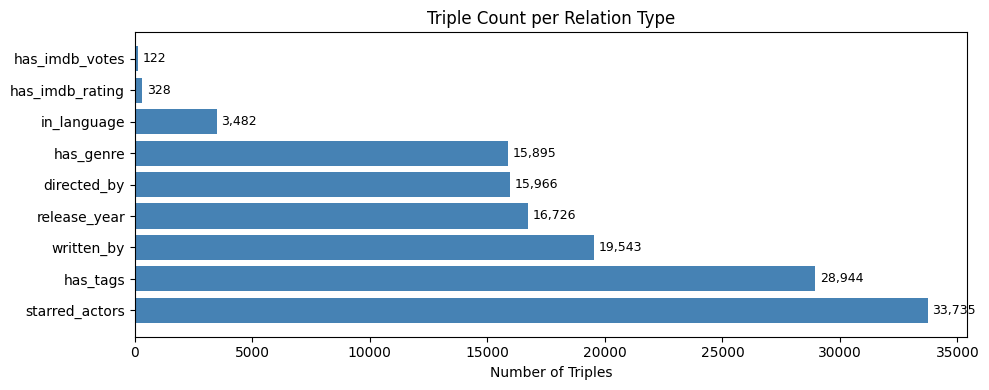

In [ ]:
#Fetching more stats                                                

relation_counts = defaultdict(int)
for _, relation, _ in triples:
    relation_counts[relation] += 1

relations_sorted = sorted(relation_counts.items(), key=lambda x: x[1], reverse=True)

labels  = [r for r, _ in relations_sorted]
counts  = [c for _, c in relations_sorted]

plt.figure(figsize=(10, 4))
bars = plt.barh(labels, counts, color='steelblue')
plt.xlabel('Number of Triples')
plt.title('Triple Count per Relation Type')
plt.tight_layout()
for bar, count in zip(bars, counts):
    plt.text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
             f'{count:,}', va='center', fontsize=9)
plt.show()


In [119]:
                                                        
out_degrees = sorted(G.out_degree(), key=lambda x: x[1], reverse=True)

print('Top 10 most connected entities in the KG:')
print(f'  {"Entity":<40} {"Out-Degree"}')
print('  ' + '-' * 52)
for entity, degree in out_degrees[:10]:
    print(f'  {entity:<40} {degree}')


Top 10 most connected entities in the KG:
  Entity                                   Out-Degree
  ----------------------------------------------------
  Hamlet                                   56
  Les Misérables                           50
  King Kong                                43
  Alice in Wonderland                      41
  Beauty and the Beast                     41
  Godzilla                                 40
  The Avengers                             40
  The Raven                                39
  Iron Man                                 38
  Pinocchio                                37


---
## Step 3  -  Entity Linking

Given a MetaQA question like `"what films were directed by [Clint Eastwood]"`, this step:
1. **Extracts** the entity mention from the `[brackets]`
2. **Matches** it to an actual node in the KG

Extraction uses bracket text. Matching uses exact lookup first, then fuzzy matching as a fallback.

In [ ]:
#Entity Linking step - In simple words, this just checks if the topic entity is present in the KG.

def extract_entity(question):
    """Pull the entity mention out of [brackets] in a MetaQA question."""
    match = re.search(r'\[(.+?)\]', question)
    if match:
        return match.group(1)
    return None


def link_entity(mention, all_entities):
    """
    Map a mention string to a node in the KG.
    Strategy:
      1. Exact match
      2. Case-insensitive exact match
      3. Fuzzy match (difflib)
    Returns (matched_entity, confidence_score)
    """
                    
    if mention in all_entities:
        return mention, 1.0

                               
    lower_map = {e.lower(): e for e in all_entities}
    if mention.lower() in lower_map:
        return lower_map[mention.lower()], 0.99

                    
    close = get_close_matches(mention, all_entities, n=1, cutoff=0.6)
    if close:
        return close[0], 0.75

    return None, 0.0


                                            
test_questions = [
    "what movies are about [ginger rogers]",
    "what films were directed by [Clint Eastwood]",
    "which movies can be described by [moore]",
    "who acted in [The Dark Knight]",
]

print(f'  {"Question":<55} {"Linked Entity":<30} {"Confidence"}')
print('  ' + '-' * 100)
for q in test_questions:
    mention = extract_entity(q)
    entity, score = link_entity(mention, all_entities)
    print(f'  {q:<55} {str(entity):<30} {score:.2f}')


  Question                                                Linked Entity                  Confidence
  ----------------------------------------------------------------------------------------------------
  what movies are about [ginger rogers]                   ginger rogers                  1.00
  what films were directed by [Clint Eastwood]            Clint Eastwood                 1.00
  which movies can be described by [moore]                moore                          1.00
  who acted in [The Dark Knight]                          The Dark Knight                1.00


---
## Step 4  -  BFS Subgraph Retrieval

**Breadth-First Search (BFS)** performs hop-by-hop graph traversal from a seed entity and collects encountered triples.

- `k=1` -> direct neighbors only (typical for 1-hop questions)
- `k=2` -> neighbors of neighbors (typical for 2-hop questions)
- `k=3` -> three levels deep (typical for 3-hop questions)
- `max_triples` -> hard cap to keep the subgraph a manageable size

In [ ]:
#Implementation of BFS algorithm

def bfs_subgraph(graph, seed_entity, k=2, max_triples=50):
    """BFS-based subgraph retrieval (bidirectional traversal).

    Note: In MetaQA, many edges point from Movie -> (Actor/Director/etc.).
    Bidirectional traversal allows traversal from any entity type.
    """
    if seed_entity not in graph:
        return []

    visited = {seed_entity}
    queue = deque([(seed_entity, 0)])               
    result = []

    while queue:
        node, hop = queue.popleft()
        if hop >= k:
            continue

                                          
        for neighbor in graph.neighbors(node):
            relation = graph[node][neighbor]["relation"]
            result.append((node, relation, neighbor))
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, hop + 1))
            if len(result) >= max_triples:
                return result

                                             
        for predecessor in graph.predecessors(node):
            relation = graph[predecessor][node]["relation"]
            result.append((predecessor, relation, node))
            if predecessor not in visited:
                visited.add(predecessor)
                queue.append((predecessor, hop + 1))
            if len(result) >= max_triples:
                return result

    return result


print("BFS function defined.")


BFS function defined.


In [ ]:
#Simple Test of BFS using a seed node                 

seed = 'Clint Eastwood'

for k in [1, 2]:
    start = time.time()
    subgraph = bfs_subgraph(G, seed, k=k, max_triples=100)
    elapsed  = (time.time() - start) * 1000      

    print(f'\nBFS k={k} from "{seed}"  ->  {len(subgraph)} triples  ({elapsed:.2f} ms)')
    print('  First 5 triples:')
    for head, rel, tail in subgraph[:5]:
        print(f'    ({head}) --[{rel}]--> ({tail})')



BFS k=1 from "Clint Eastwood"  ->  57 triples  (0.15 ms)
  First 5 triples:
    (Flags of Our Fathers) --[directed_by]--> (Clint Eastwood)
    (The Bridges of Madison County) --[starred_actors]--> (Clint Eastwood)
    (High Plains Drifter) --[starred_actors]--> (Clint Eastwood)
    (The Eiger Sanction) --[starred_actors]--> (Clint Eastwood)
    (The Gauntlet) --[starred_actors]--> (Clint Eastwood)

BFS k=2 from "Clint Eastwood"  ->  100 triples  (0.09 ms)
  First 5 triples:
    (Flags of Our Fathers) --[directed_by]--> (Clint Eastwood)
    (The Bridges of Madison County) --[starred_actors]--> (Clint Eastwood)
    (High Plains Drifter) --[starred_actors]--> (Clint Eastwood)
    (The Eiger Sanction) --[starred_actors]--> (Clint Eastwood)
    (The Gauntlet) --[starred_actors]--> (Clint Eastwood)


---
## Step 5  -  End-to-End Pipeline

This section runs the complete pipeline:
**Question -> Entity Extraction -> Entity Linking -> BFS Retrieval -> Triples Output**

Example questions are taken from each hop level of the MetaQA test set.

In [123]:
def run_pipeline(question, graph, all_entities, k=2, max_triples=50):
    """
    Full pipeline for a single question.
    Returns a dict with all intermediate results and timing.
    """
    t0 = time.time()

                                                  
    mention = extract_entity(question)

                                     
    t1 = time.time()
    entity, confidence = link_entity(mention, all_entities)
    link_time = (time.time() - t1) * 1000

                                    
    t2 = time.time()
    subgraph = bfs_subgraph(graph, entity, k=k, max_triples=max_triples) if entity else []
    retrieval_time = (time.time() - t2) * 1000

    return {
        'question'      : question,
        'mention'       : mention,
        'entity'        : entity,
        'confidence'    : confidence,
        'subgraph'      : subgraph,
        'link_time_ms'  : link_time,
        'retrieval_ms'  : retrieval_time,
    }


def print_result(result, ground_truth=None, show_triples=5):
    print('\n' + '=' * 65)
    print(f'  Question  : {result["question"]}')
    if ground_truth:
        print(f'  Answer(s) : {ground_truth}')
    print(f'  Mention   : {result["mention"]}')
    print(f'  KG Entity : {result["entity"]}  (confidence: {result["confidence"]:.2f})')
    print(f'  Triples   : {len(result["subgraph"])} retrieved')
    print(f'  Timing    : linking={result["link_time_ms"]:.1f}ms  retrieval={result["retrieval_ms"]:.1f}ms')
    print(f'  Sample triples:')
    for head, rel, tail in result['subgraph'][:show_triples]:
        print(f'    ({head}) --[{rel}]--> ({tail})')
    print('=' * 65)


print('Pipeline functions defined.')


Pipeline functions defined.


In [ ]:
#Loads sample QA pairs from the test dataset                                                

def load_qa(path, n=3):
    """Load the first n (question, answers) pairs from a QA file."""
    samples = []
    with open(path) as f:
        for i, line in enumerate(f):
            if i >= n:
                break
            parts = line.strip().split('\t')
            if len(parts) == 2:
                samples.append((parts[0], parts[1]))
    return samples

samples_1hop = load_qa(QA_1HOP_TEST, n=2)
samples_2hop = load_qa(QA_2HOP_TEST, n=2)
samples_3hop = load_qa(QA_3HOP_TEST, n=2)

print('Loaded sample questions.')


Loaded sample questions.


In [ ]:
                               
#Run 1-hop questions using the pipeline
print('\n### 1-HOP QUESTIONS  (BFS k=1) ###')
for question, answers in samples_1hop:
    result = run_pipeline(question, G, all_entities, k=1)
    print_result(result, ground_truth=answers)



### 1-HOP QUESTIONS  (BFS k=1) ###

  Question  : what does [Grégoire Colin] appear in
  Answer(s) : Before the Rain
  Mention   : Grégoire Colin
  KG Entity : Grégoire Colin  (confidence: 1.00)
  Triples   : 1 retrieved
  Timing    : linking=0.0ms  retrieval=0.2ms
  Sample triples:
    (Before the Rain) --[starred_actors]--> (Grégoire Colin)

  Question  : [Joe Thomas] appears in which movies
  Answer(s) : The Inbetweeners Movie|The Inbetweeners 2
  Mention   : Joe Thomas
  KG Entity : Joe Thomas  (confidence: 1.00)
  Triples   : 2 retrieved
  Timing    : linking=0.0ms  retrieval=0.0ms
  Sample triples:
    (The Inbetweeners 2) --[starred_actors]--> (Joe Thomas)
    (The Inbetweeners Movie) --[starred_actors]--> (Joe Thomas)


In [ ]:
                               
#Run 2-hop questions using the pipeline
print('\n### 2-HOP QUESTIONS  (BFS k=2) ###')
for question, answers in samples_2hop:
    result = run_pipeline(question, G, all_entities, k=2)
    print_result(result, ground_truth=answers)



### 2-HOP QUESTIONS  (BFS k=2) ###

  Question  : which person directed the movies starred by [John Krasinski]
  Answer(s) : Nancy Meyers|Sam Mendes|George Clooney|Ken Kwapis|Luke Greenfield
  Mention   : John Krasinski
  KG Entity : John Krasinski  (confidence: 1.00)
  Triples   : 50 retrieved
  Timing    : linking=0.0ms  retrieval=0.2ms
  Sample triples:
    (Leatherheads) --[starred_actors]--> (John Krasinski)
    (Away We Go) --[starred_actors]--> (John Krasinski)
    (License to Wed) --[starred_actors]--> (John Krasinski)
    (Something Borrowed) --[starred_actors]--> (John Krasinski)
    (It's Complicated) --[starred_actors]--> (John Krasinski)

  Question  : who are movie co-directors of [Delbert Mann]
  Answer(s) : Franco Zeffirelli|Cary Fukunaga|Lewis Milestone|Robert Stevenson
  Mention   : Delbert Mann
  KG Entity : Delbert Mann  (confidence: 1.00)
  Triples   : 50 retrieved
  Timing    : linking=0.0ms  retrieval=0.3ms
  Sample triples:
    (Lover Come Back) --[directed_by]

In [ ]:
                               
#Run 3-hop questions using the pipeline
print('\n### 3-HOP QUESTIONS  (BFS k=3) ###')
for question, answers in samples_3hop:
    result = run_pipeline(question, G, all_entities, k=3, max_triples=500)
    print_result(result, ground_truth=answers)



### 3-HOP QUESTIONS  (BFS k=3) ###

  Question  : the films that share directors with the film [Catch Me If You Can] were in which languages
  Answer(s) : German|Polish|Mende|Japanese
  Mention   : Catch Me If You Can
  KG Entity : Catch Me If You Can  (confidence: 1.00)
  Triples   : 500 retrieved
  Timing    : linking=0.0ms  retrieval=9.8ms
  Sample triples:
    (Catch Me If You Can) --[directed_by]--> (Steven Spielberg)
    (Catch Me If You Can) --[starred_actors]--> (Leonardo DiCaprio)
    (Catch Me If You Can) --[starred_actors]--> (Tom Hanks)
    (Catch Me If You Can) --[starred_actors]--> (Christopher Walken)
    (Catch Me If You Can) --[starred_actors]--> (Martin Sheen)

  Question  : who starred movies for the director of [Written on the Wind]
  Answer(s) : Sandra Dee|Charles Coburn|Cornel Wilde|John Gavin|Warren William|Susan Kohner|Joan Bennett|Fred MacMurray|Barbara Stanwyck|Don Ameche|Jane Wyman|Rochelle Hudson|Boris Karloff|Patricia Knight|Robert Cummings|Rock Hudson|Luc

---
## Step 6  -  BFS Recall Check  *(BFS baseline only)*

A quick check of BFS answer coverage on a handful of questions per hop.
**Full multi-algorithm evaluation with varied budgets is in Step 10.**

In [ ]:
def compute_recall(subgraph, ground_truth_str):
    """Return (recall, hits) for a BFS subgraph against pipe-separated answer string."""
    answers  = set(ground_truth_str.strip().split('|'))
    entities = {node for h, _, t in subgraph for node in (h, t)}
    hits     = answers & entities
    recall   = len(hits) / len(answers) if answers else 0.0
    return recall, hits
                                                 
all_samples = [
    (1, samples_1hop, 1),
    (2, samples_2hop, 2),
    (3, samples_3hop, 3),
]
print(f'  {"Hop":<4} {"Recall":<8}  Question')
print('  ' + '-' * 72)
for hop, samples, k in all_samples:
    for question, answers in samples[:3]:
        result = run_pipeline(question, G, all_entities, k=k, max_triples=200)
        recall, _ = compute_recall(result['subgraph'], answers)
        print(f'  {hop:<4} {recall:<8.2f}  {question[:60]}')


  Hop  Recall    Question
  ------------------------------------------------------------------------
  1    1.00      what does [Grégoire Colin] appear in
  1    1.00      [Joe Thomas] appears in which movies
  2    1.00      which person directed the movies starred by [John Krasinski]
  2    1.00      who are movie co-directors of [Delbert Mann]
  3    0.00      the films that share directors with the film [Catch Me If Yo
  3    0.05      who starred movies for the director of [Written on the Wind]


---
## Step 7  -  BFS Subgraph Size vs Hops  *(BFS baseline only)*

As **k** increases, the BFS neighborhood grows exponentially.  This motivates using a
**retrieval budget** (`top_k`) to cap the context sent to the LLM, and using smarter
ranking algorithms (PPR, Top-K Scoring) that prioritize within that budget.

  k=1: 57 triples in 1.5 ms
  k=2: 658 triples in 1.5 ms
  k=3: 10000 triples in 28.8 ms


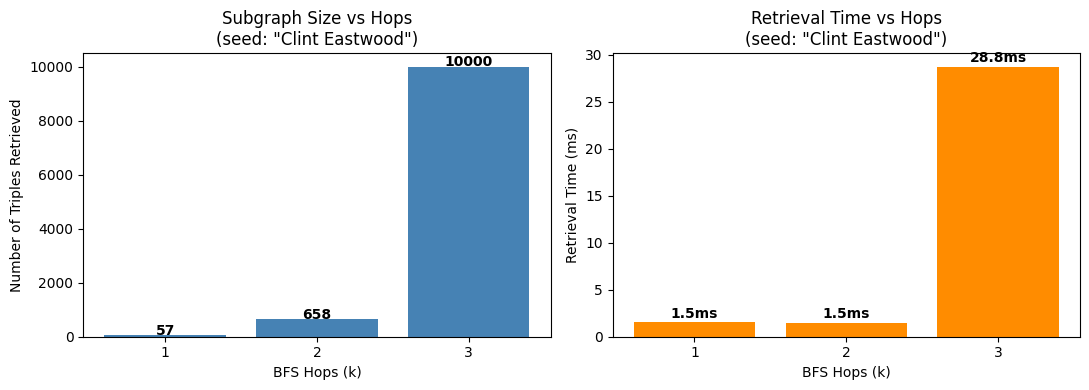

In [129]:
                                   
seed = 'Clint Eastwood'

hop_values    = [1, 2, 3]
subgraph_sizes = []
retrieval_times = []

for k in hop_values:
    t = time.time()
    sg = bfs_subgraph(G, seed, k=k, max_triples=10000)
    elapsed = (time.time() - t) * 1000
    subgraph_sizes.append(len(sg))
    retrieval_times.append(elapsed)
    print(f'  k={k}: {len(sg)} triples in {elapsed:.1f} ms')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.bar([str(k) for k in hop_values], subgraph_sizes, color='steelblue')
ax1.set_xlabel('BFS Hops (k)')
ax1.set_ylabel('Number of Triples Retrieved')
ax1.set_title(f'Subgraph Size vs Hops\n(seed: "{seed}")')
for i, v in enumerate(subgraph_sizes):
    ax1.text(i, v + 10, str(v), ha='center', fontweight='bold')

ax2.bar([str(k) for k in hop_values], retrieval_times, color='darkorange')
ax2.set_xlabel('BFS Hops (k)')
ax2.set_ylabel('Retrieval Time (ms)')
ax2.set_title(f'Retrieval Time vs Hops\n(seed: "{seed}")')
for i, v in enumerate(retrieval_times):
    ax2.text(i, v + 0.5, f'{v:.1f}ms', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


---
## Algorithms

Four subgraph retrieval algorithms are implemented and compared in **Step 11**.

| Algorithm | Where defined | Key idea |
|---|---|---|
| **BFS** | Step 4 | Collects all triples within *k* hops; simple, exhaustive |
| **PPR** | Step 8 | Personalized PageRank on the **undirected** graph; structurally-ranked |
| **Top-K Scoring** | Step 9 | BFS candidates re-ranked by word-overlap with the question |
| **Beam Search** | Step 10 | Question-guided traversal; keeps only top `beam_width` frontier nodes per hop |

---
## Step 8  -  PPR Subgraph Retrieval

**Personalized PageRank (PPR)** assigns an importance score to every node in the graph by
biasing random walks to *restart at the seed entity* with probability `1 - alpha`.

Nodes that are structurally close to the seed — or strongly connected through shared
neighbours — accumulate higher scores.  Every triple is then scored by the **sum of
its two endpoint PPR values**, and the top-K triples are returned.

Key difference from BFS: instead of blindly collecting *everything within k hops*,
PPR returns the **most structurally relevant** triples without needing a hop bound.
No `max_triples` cap is needed because the ranking itself filters noise.

In [130]:
def ppr_subgraph(graph, seed_entity, top_k=50, alpha=0.85):
    """Personalized PageRank (PPR) subgraph retrieval.

    Runs PageRank with a personalization vector concentrated entirely on
    seed_entity.  At each step a random walker follows an edge with
    probability alpha, or teleports back to seed_entity with probability
    1-alpha.  Nodes reachable from — and strongly tied to — the seed end
    up with higher scores.

    Every directed edge in the graph is scored by the SUM of the PPR
    values of its head and tail nodes.  The top_k edges are returned as
    (head, relation, tail) triples.

    Parameters
    ----------
    graph       : NetworkX DiGraph built from kb.txt
    seed_entity : starting node (must exist in the graph)
    top_k       : number of triples to return
    alpha       : damping / continuation probability (0 < alpha < 1)
    """
    if seed_entity not in graph:
        return []

                                                                 
    personalization = {node: 0.0 for node in graph.nodes()}
    personalization[seed_entity] = 1.0

                                                        
    scores = nx.pagerank(graph, alpha=alpha, personalization=personalization)

                                                            
    scored_triples = [
        (scores.get(h, 0.0) + scores.get(t, 0.0), h, data['relation'], t)
        for h, t, data in graph.edges(data=True)
    ]

                                            
    scored_triples.sort(key=lambda x: x[0], reverse=True)
    return [(h, r, t) for _, h, r, t in scored_triples[:top_k]]


print('PPR function defined.')


PPR function defined.


In [ ]:
#Demo of PPR on a seed entity with top 50 triples set as budget                                                                                 
                                                                           
                                                                                   
seed = 'Clint Eastwood'

start = time.time()
ppr_sg = ppr_subgraph(G_undirected, seed, top_k=50)
elapsed = (time.time() - start) * 1000

print(f'PPR (undirected) from "{seed}"  ->  {len(ppr_sg)} triples  ({elapsed:.0f} ms)')
print('\nTop 5 triples (highest PPR-scored):')
for h, r, t in ppr_sg[:5]:
    print(f'  ({h}) --[{r}]--> ({t})')


PPR (undirected) from "Clint Eastwood"  ->  50 triples  (327 ms)

Top 5 triples (highest PPR-scored):
  (Clint Eastwood) --[starred_actors]--> (Gran Torino)
  (Clint Eastwood) --[starred_actors]--> (Any Which Way You Can)
  (Clint Eastwood) --[starred_actors]--> (A Fistful of Dollars)
  (Clint Eastwood) --[starred_actors]--> (The Good, the Bad and the Ugly)
  (Clint Eastwood) --[starred_actors]--> (Magnum Force)


---
## Step 9  -  Top-K Triple Scoring

**Algorithm:**
1. Collect *all* candidate triples within k hops using BFS (large cap so nothing is dropped)
2. Score every triple by **word-overlap** with the question
   - Relation underscores are expanded (`directed_by` → `directed by`)
   - A 5-character prefix is used as a naive stem so that `directed` and `directors`
     both reduce to `direc` and match each other
3. Return the top-K highest-scoring triples

Key difference from BFS and PPR: this method uses the **question text** directly —
not just graph structure — so it can focus on triples whose relation types are
semantically mentioned in the question (e.g. `directed_by` for "directed" questions).

In [ ]:
#Removal of stop words to filter stems for a given question and top-k scoring algorithm
_STOP_WORDS = {
    'the', 'a', 'an', 'in', 'of', 'is', 'are', 'what', 'which',
    'who', 'where', 'when', 'how', 'does', 'do', 'by', 'for',
    'that', 'with', 'this', 'was', 'were', 'movies', 'films',
    'movie', 'film', 'and', 'or', 'to', 'from', 'about',
    'appear', 'appears', 'have', 'had', 'has', 'been',
    'person', 'people', 'share', 'shares',
}


def _question_stems(question):
    """Return the set of 5-char prefix stems of content words in the question.

    The bracketed entity (e.g. [Clint Eastwood]) is stripped before tokenising
    so the seed entity does not dominate the score.
    """
    raw   = re.sub(r'\[.*?\]', '', question)
    words = re.findall(r'\w+', raw.lower())
    return {w[:5] for w in words if w not in _STOP_WORDS and len(w) >= 4}


def _score_triple(q_stems, head, relation, tail):
    """Fraction of question stems that match at least one stem in the triple."""
    if not q_stems:
        return 0.0
    triple_text = f"{head} {relation.replace('_', ' ')} {tail}".lower()
    t_stems     = {w[:5] for w in re.findall(r'\w+', triple_text) if len(w) >= 4}
    return len(q_stems & t_stems) / len(q_stems)


def topk_scoring_subgraph(graph, seed_entity, question, k_hop=2, top_k=50):
    """Top-K Triple Scoring subgraph retrieval (SubgraphRAG-inspired).

    Parameters
    ----------
    graph       : NetworkX DiGraph
    seed_entity : seed node (must exist in graph)
    question    : natural-language question (used for scoring)
    k_hop       : hop depth for candidate collection
    top_k       : number of triples to return
    """
    if seed_entity not in graph:
        return []

                                                                                
    candidates = bfs_subgraph(graph, seed_entity, k=k_hop, max_triples=50_000)
    if not candidates:
        return []

                                   
    q_stems = _question_stems(question)
    scored  = [(_score_triple(q_stems, h, r, t), h, r, t) for h, r, t in candidates]

                                                                                    
    scored.sort(key=lambda x: x[0], reverse=True)
    return [(h, r, t) for _, h, r, t in scored[:top_k]]


print('Top-K Scoring functions defined.')


Top-K Scoring functions defined.


In [ ]:
                                                                      
#Demo of top-k on a seed entity
seed     = 'Clint Eastwood'
question = 'which person directed the movies starred by [Clint Eastwood]'

start   = time.time()
topk_sg = topk_scoring_subgraph(G, seed, question, k_hop=2, top_k=50)
elapsed = (time.time() - start) * 1000

print(f'Top-K Scoring from "{seed}"  ->  {len(topk_sg)} triples  ({elapsed:.0f} ms)')
print(f'\nQuestion: "{question}"')
print('\nTop 5 triples (highest question-overlap score):')
for h, r, t in topk_sg[:5]:
    print(f'  ({h}) --[{r}]--> ({t})')


Top-K Scoring from "Clint Eastwood"  ->  50 triples  (6 ms)

Question: "which person directed the movies starred by [Clint Eastwood]"

Top 5 triples (highest question-overlap score):
  (Flags of Our Fathers) --[directed_by]--> (Clint Eastwood)
  (The Bridges of Madison County) --[starred_actors]--> (Clint Eastwood)
  (High Plains Drifter) --[starred_actors]--> (Clint Eastwood)
  (The Eiger Sanction) --[starred_actors]--> (Clint Eastwood)
  (The Gauntlet) --[starred_actors]--> (Clint Eastwood)


---
## Step 10  -  Beam Search Subgraph Retrieval

**Beam Search** performs a question-guided, bidirectional traversal.
At each hop it expands candidate neighbours, then keeps only the top `beam_width` frontier nodes.
After traversal, all collected triples are re-ranked by question overlap and the top-K are returned.

In [ ]:
#Beam search helpers and algorithm

def _score_relation_only(q_stems, relation):
    """Score overlap between question stems and relation-name stems only."""
    if not q_stems:
        return 0.0
    rel_text = relation.replace('_', ' ').lower()
    r_stems  = {w[:5] for w in re.findall(r'\w+', rel_text) if len(w) >= 4}
    return len(q_stems & r_stems) / len(q_stems)


def beam_search_subgraph(graph, seed_entity, question, k_hop=2, beam_width=25,
                         top_k=50, max_triples=50_000):
    """Beam Search subgraph retrieval (bidirectional, question-guided).

    Parameters
    ----------
    graph       : NetworkX DiGraph
    seed_entity : starting node
    question    : natural-language question (used to score triples)
    k_hop       : hop depth
    beam_width  : base beam width; per-hop frontier budgets scale this value
    top_k       : number of triples to return after re-ranking
    max_triples : cap on collected candidates before final re-ranking
    """
    if seed_entity not in graph:
        return []

    q_stems = _question_stems(question)

    visited  = {seed_entity}
    frontier = [seed_entity]
                                   
    triples = []

    for hop_idx in range(k_hop):
                                                               
        if hop_idx == 0:
            bw = int(beam_width * 2)
        elif hop_idx == k_hop - 1:
            bw = int(beam_width)
        else:
            bw = int(beam_width * 1.5)
        bw = max(1, bw)

                                                                                          
        candidate_nodes = {}

        for node in frontier:
                                         
            for nbr in graph.neighbors(node):
                rel = graph[node][nbr]['relation']
                triples.append((node, rel, nbr))
                if len(triples) >= max_triples:
                    break

                if nbr not in visited:
                    s_rel = _score_relation_only(q_stems, rel)
                    prev  = candidate_nodes.get(nbr)
                    if prev is None or s_rel > prev:
                        candidate_nodes[nbr] = s_rel

            if len(triples) >= max_triples:
                break

                                          
            for pred in graph.predecessors(node):
                rel = graph[pred][node]['relation']
                triples.append((pred, rel, node))
                if len(triples) >= max_triples:
                    break

                if pred not in visited:
                    s_rel = _score_relation_only(q_stems, rel)
                    prev  = candidate_nodes.get(pred)
                    if prev is None or s_rel > prev:
                        candidate_nodes[pred] = s_rel

            if len(triples) >= max_triples:
                break

        if not candidate_nodes:
            break

                                                     
        ranked_nodes = sorted(candidate_nodes.items(), key=lambda kv: kv[1], reverse=True)
        frontier     = [n for n, _ in ranked_nodes[:bw]]
        visited.update(frontier)

                                                                     
    scored_triples = [(_score_triple(q_stems, h, r, t), h, r, t) for h, r, t in triples]
    scored_triples.sort(key=lambda x: x[0], reverse=True)
    return [(h, r, t) for _, h, r, t in scored_triples[:top_k]]


def _beam_ranked_all(graph, seed_entity, question, k_hop, beam_width=25):
    """Run Beam Search once; return ranked triples + timing (ms)."""
    if seed_entity not in graph:
        return [], 0.0
    t0 = time.time()

                                                           
    ranked = beam_search_subgraph(
        graph, seed_entity, question,
        k_hop=k_hop,
        beam_width=beam_width,
        top_k=50_000,                                               
        max_triples=50_000,
    )
    ms = (time.time() - t0) * 1000
    return ranked, ms


print('Beam Search defined.')

                                                                                
demo_seed  = 'Clint Eastwood'
demo_q     = 'which person directed the movies starred by [Clint Eastwood]'
beam_rank, beam_ms = _beam_ranked_all(G, demo_seed, demo_q, k_hop=2, beam_width=25)
print(f'Beam Search from "{demo_seed}" -> {len(beam_rank[:50])} triples  ({beam_ms:.2f} ms)')
print('Top 5 Beam triples:')
for h, r, t in beam_rank[:5]:
    print(f'  ({h}) --[{r}]--> ({t})')


Beam Search defined.
Beam Search from "Clint Eastwood" -> 50 triples  (4.67 ms)
Top 5 Beam triples:
  (Flags of Our Fathers) --[directed_by]--> (Clint Eastwood)
  (The Bridges of Madison County) --[starred_actors]--> (Clint Eastwood)
  (High Plains Drifter) --[starred_actors]--> (Clint Eastwood)
  (The Eiger Sanction) --[starred_actors]--> (Clint Eastwood)
  (The Gauntlet) --[starred_actors]--> (Clint Eastwood)


---
## Step 11  -  Final Comparative Evaluation

All four algorithms evaluated together across **budgets of 20 → 500 triples** and
**50 questions per hop level** (150 questions total).

| Design choice | Reason |
|---|---|
| **PPR on undirected graph** | MetaQA edges point Movie→Person; PPR from a Person seed stalls on the directed graph because the seed has no outgoing edges.  Undirected graph lets walks propagate outward. |
| **Vary budget (top\_k)** | Shows how quickly each algorithm saturates in recall as more triples are returned — key for the accuracy vs. efficiency tradeoff analysis. |
| **50 questions/hop** | Enough for statistically stable averages; small enough to finish in ~1 min. |

**Metrics reported**

| Metric | Meaning |
|---|---|
| **Recall** | Fraction of ground-truth answers found in the returned subgraph |
| **Hit Rate** | Binary: was *at least one* answer found? (useful for QA success-rate reporting) |
| **Time (ms)** | Wall-clock retrieval time per query |
| **MRR** | Reciprocal rank of the first retrieved triple that mentions an answer entity |

In [ ]:
#Final evaluation metrics                                                     
                                                                                
samples_1hop_L = load_qa(QA_1HOP_TEST, n=50)
samples_2hop_L = load_qa(QA_2HOP_TEST, n=50)
samples_3hop_L = load_qa(QA_3HOP_TEST, n=50)

all_samples_L = [
    (1, samples_1hop_L, 1),
    (2, samples_2hop_L, 2),
    (3, samples_3hop_L, 3),
]
print(f'Loaded {sum(len(s) for _, s, _ in all_samples_L)} questions '
      f'({len(samples_1hop_L)} / {len(samples_2hop_L)} / {len(samples_3hop_L)} per hop)')

                                                                                
def compute_metrics(subgraph, ground_truth_str):
    """Return (recall, hit_rate, mrr) for a retrieved subgraph.

    All unique nodes (head + tail) in the returned triples form the retrieved
    entity set. hit_rate is binary: 1.0 if at least one answer was found.

    MRR per question = 1/rank of the first retrieved triple whose head or tail
    node appears in the ground-truth answer set. If no answer entity is found in
    the ranked list, MRR = 0.0.
    """
    answers  = set(ground_truth_str.strip().split('|'))
    entities = {node for h, _, t in subgraph for node in (h, t)}
    hits      = answers & entities

    recall    = len(hits) / len(answers) if answers else 0.0
    hit_rate  = 1.0 if hits else 0.0

    mrr = 0.0
    if answers:
        for i, (h, _, t) in enumerate(subgraph, start=1):
            if h in answers or t in answers:
                mrr = 1.0 / i
                break

    return recall, hit_rate, mrr

                                                                                
def _ppr_ranked_all(graph, seed_entity, alpha=0.85):
    """PPR: run PageRank once, return ALL edges sorted by score + time (ms).
    Caller slices to the desired budget — avoids re-running PageRank per budget.
    """
    if seed_entity not in graph:
        return [], 0.0
    personalization = {node: 0.0 for node in graph.nodes()}
    personalization[seed_entity] = 1.0
    t0     = time.time()
    scores = nx.pagerank(graph, alpha=alpha, personalization=personalization)
    ppr_ms = (time.time() - t0) * 1000
    scored = [
        (scores.get(h, 0.0) + scores.get(t, 0.0), h, data['relation'], t)
        for h, t, data in graph.edges(data=True)
    ]
    scored.sort(key=lambda x: x[0], reverse=True)
    return [(h, r, t) for _, h, r, t in scored], ppr_ms


def _topk_ranked_all(graph, seed_entity, question, k_hop):
    """Top-K: collect BFS candidates + score once, return sorted list + time (ms).
    Caller slices to the desired budget — avoids re-running BFS+scoring per budget.
    """
    if seed_entity not in graph:
        return [], 0.0
    t0      = time.time()
    cands   = bfs_subgraph(graph, seed_entity, k=k_hop, max_triples=50_000)
    q_stems = _question_stems(question)
    scored  = [(_score_triple(q_stems, h, r, t), h, r, t) for h, r, t in cands]
    scored.sort(key=lambda x: x[0], reverse=True)
    ms      = (time.time() - t0) * 1000
    return [(h, r, t) for _, h, r, t in scored], ms


print('Setup complete.')


Loaded 150 questions (50 / 50 / 50 per hop)
Setup complete.


In [ ]:
#Compute metrics for different budget values and all algorithms

TOP_K_VALUES = [20, 50, 100, 200, 500, 1000]
ALGOS        = ['BFS', 'PPR', 'Top-K Score', 'Beam Search']

                                                                   
final_results = {
    a: {h: {k: {'recall': [], 'hit': [], 'mrr': [], 'time_ms': []}
             for k in TOP_K_VALUES}
        for h in [1, 2, 3]}
    for a in ALGOS
}

for hop, samples, k_hop in all_samples_L:
    print(f'  {hop}-hop ({len(samples)} questions)  ', end='', flush=True)
    t_hop = time.time()

    for question, answers in samples:
        mention   = extract_entity(question)
        entity, _ = link_entity(mention, all_entities)
        if not entity:
            continue

                                                                          
        ppr_ranked,   ppr_ms   = _ppr_ranked_all(G_undirected, entity)
        topk_ranked,  topk_ms  = _topk_ranked_all(G, entity, question, k_hop)
        beam_ranked,  beam_ms  = _beam_ranked_all(G, entity, question, k_hop, beam_width=25)

        for top_k in TOP_K_VALUES:
                                                                        
            t0     = time.time()
            bfs_sg = bfs_subgraph(G, entity, k=k_hop, max_triples=top_k)
            bfs_ms = (time.time() - t0) * 1000

            for algo, sg, ms in [
                ('BFS',         bfs_sg,             bfs_ms),
                ('PPR',         ppr_ranked[:top_k],  ppr_ms),
                ('Top-K Score', topk_ranked[:top_k], topk_ms),
                ('Beam Search', beam_ranked[:top_k],  beam_ms),
            ]:
                r, hr, mrr = compute_metrics(sg, answers)
                d = final_results[algo][hop][top_k]
                d['recall'].append(r);   d['hit'].append(hr)
                d['mrr'].append(mrr)
                d['time_ms'].append(ms)

    print(f'{time.time() - t_hop:.0f}s')

print('\nEvaluation complete.')


  1-hop (50 questions)  14s
  2-hop (50 questions)  13s
  3-hop (50 questions)  18s

Evaluation complete.


Algorithm      Hop   Budget   Recall   HitRate     MRR   Time(ms)  N
────────────────────────────────────────────────────────────────────────
BFS            1         20    1.000     1.000   0.987        0.0  50
               1         50    1.000     1.000   0.987        0.0  50
               1        100    1.000     1.000   0.987        0.0  50
               1        200    1.000     1.000   0.987        0.0  50
               1        500    1.000     1.000   0.987        0.0  50
               1       1000    1.000     1.000   0.987        0.0  50
               2         20    0.678     0.860   0.163        0.0  50
               2         50    0.911     0.980   0.168        0.0  50
               2        100    0.966     0.980   0.168        0.0  50
               2        200    0.996     1.000   0.168        0.0  50
               2        500    1.000     1.000   0.168        0.1  50
               2       1000    1.000     1.000   0.168        0.1  50
               3  

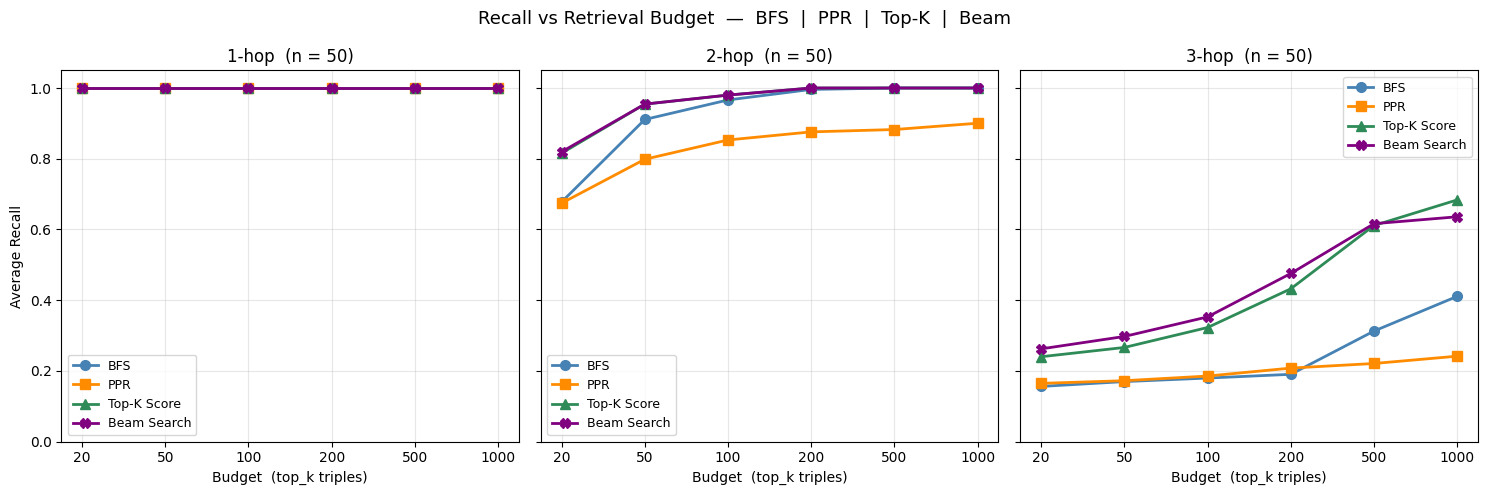

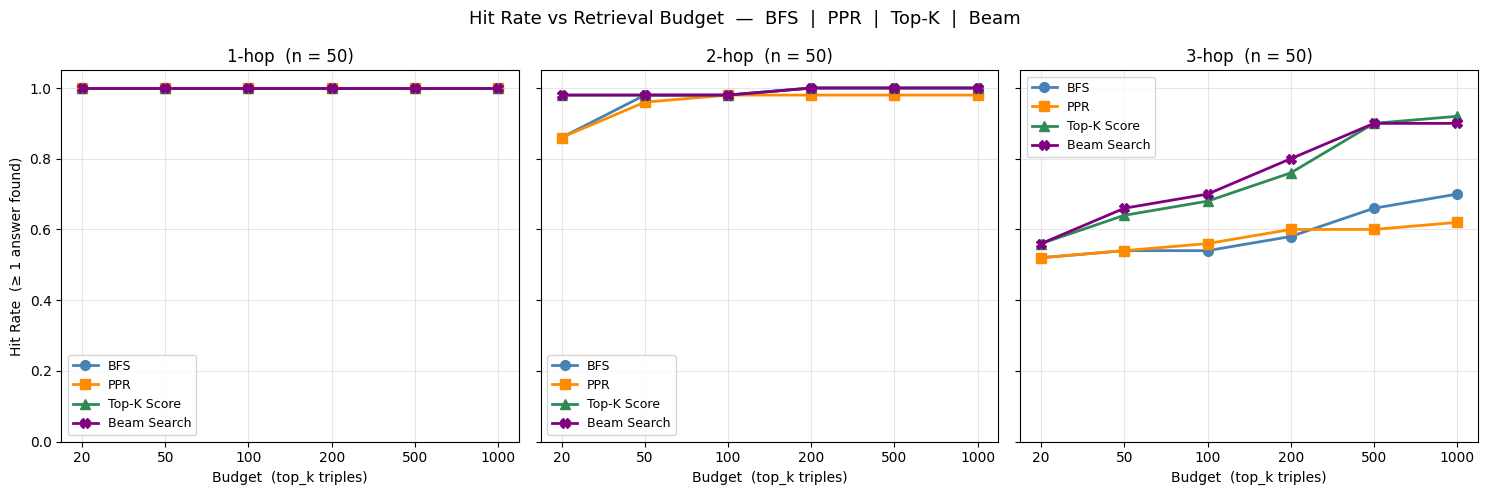

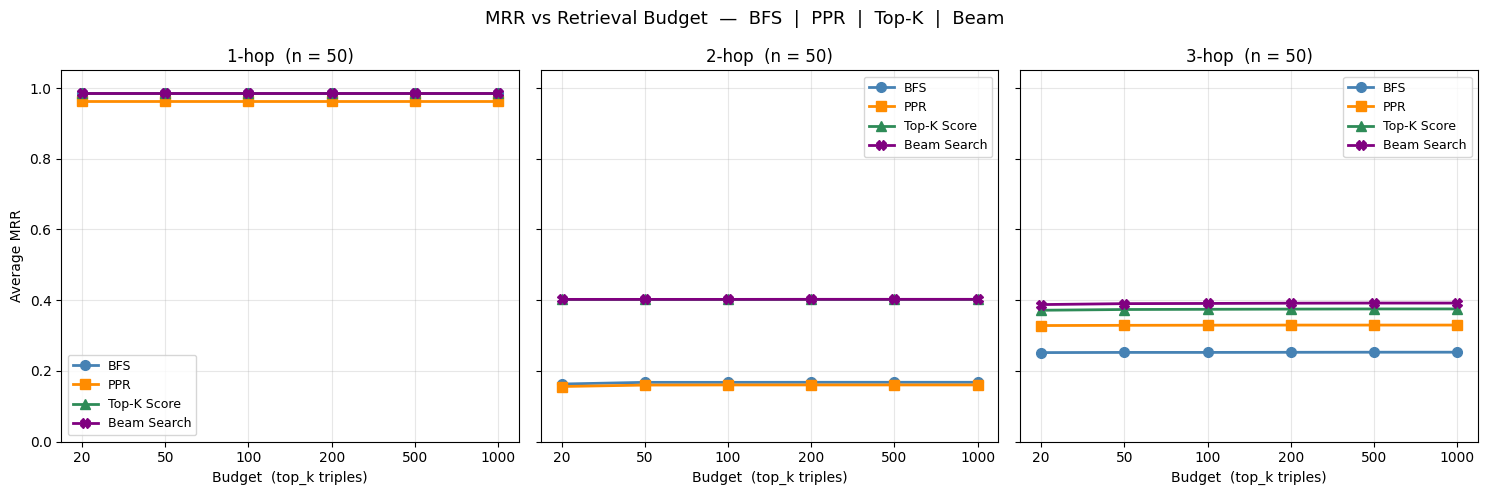

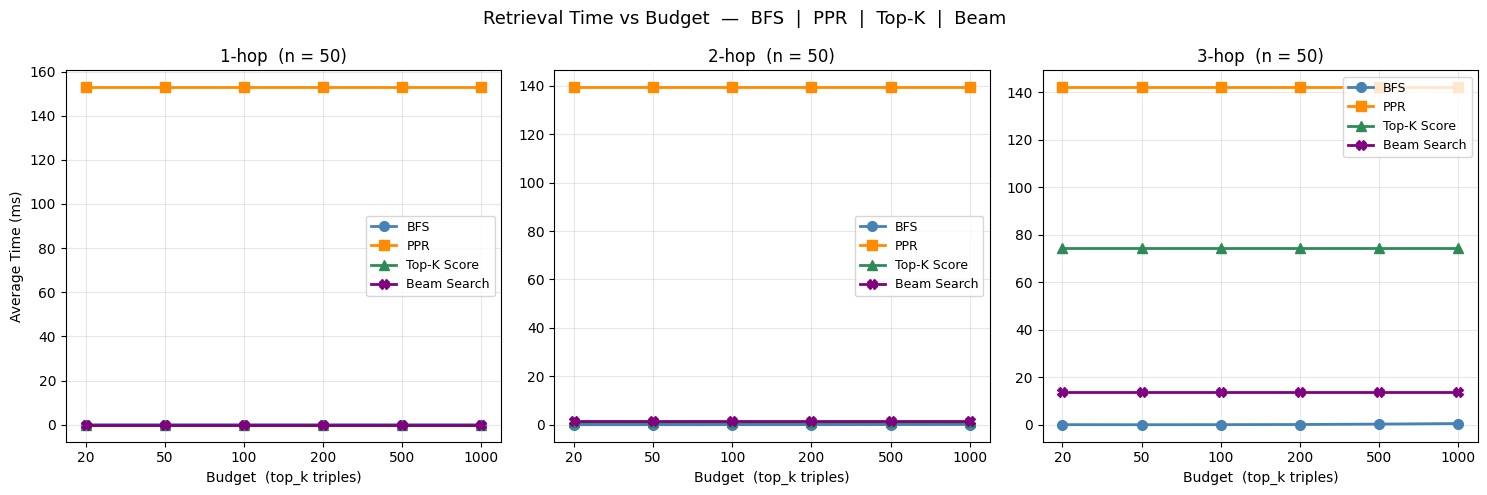

Results saved → /Users/spartan/Desktop/CS 255 Project/kg-subgraph-retrieval/results_summary.json


In [ ]:
#Print averages and plots graphs for all metrics

def _avg(lst): return sum(lst) / len(lst) if lst else 0.0

                                                                                
print(f'{"Algorithm":<14} {"Hop":<4} {"Budget":>7}  '
      f'{"Recall":>7}  {"HitRate":>8}  {"MRR":>6}  {"Time(ms)":>9}  N')
print('─' * 72)

for algo in ALGOS:
    first = True
    for hop in [1, 2, 3]:
        for top_k in TOP_K_VALUES:
            d = final_results[algo][hop][top_k]
            n = len(d['recall'])
            if n == 0:
                continue
            r  = _avg(d['recall'])
            hr = _avg(d['hit'])
            t   = _avg(d['time_ms'])
            mrr = _avg(d['mrr'])
            lbl = algo if first else ''
            first = False
            print(f'{lbl:<14} {hop:<4} {top_k:>7}  '
                  f'{r:>7.3f}  {hr:>8.3f}  {mrr:>6.3f}  {t:>9.1f}  {n}')
    print()

                                                                                
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
palette  = {
    'BFS': 'steelblue',
    'PPR': 'darkorange',
    'Top-K Score': 'seagreen',
    'Beam Search': 'purple',
}
markers  = {
    'BFS': 'o',
    'PPR': 's',
    'Top-K Score': '^',
    'Beam Search': 'X',
}
n_labels = {1: len(samples_1hop_L), 2: len(samples_2hop_L), 3: len(samples_3hop_L)}
x        = list(range(len(TOP_K_VALUES)))

for ax, hop in zip(axes, [1, 2, 3]):
    for algo in ALGOS:
        vals = [_avg(final_results[algo][hop][k]['recall']) for k in TOP_K_VALUES]
        ax.plot(x, vals, marker=markers[algo], color=palette[algo],
                label=algo, linewidth=2, markersize=7)
    ax.set_xticks(x)
    ax.set_xticklabels(TOP_K_VALUES)
    ax.set_xlabel('Budget  (top_k triples)')
    if hop == 1:
        ax.set_ylabel('Average Recall')
    ax.set_ylim(0, 1.05)
    ax.set_title(f'{hop}-hop  (n = {n_labels[hop]})')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('Recall vs Retrieval Budget  —  BFS  |  PPR  |  Top-K  |  Beam',
             fontsize=13)
plt.tight_layout()
plt.show()

                                                                               
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, hop in zip(axes2, [1, 2, 3]):
    for algo in ALGOS:
        vals = [_avg(final_results[algo][hop][k]['hit']) for k in TOP_K_VALUES]
        ax.plot(x, vals, marker=markers[algo], color=palette[algo],
                label=algo, linewidth=2, markersize=7)
    ax.set_xticks(x)
    ax.set_xticklabels(TOP_K_VALUES)
    ax.set_xlabel('Budget  (top_k triples)')
    if hop == 1:
        ax.set_ylabel('Hit Rate  (≥ 1 answer found)')
    ax.set_ylim(0, 1.05)
    ax.set_title(f'{hop}-hop  (n = {n_labels[hop]})')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig2.suptitle('Hit Rate vs Retrieval Budget  —  BFS  |  PPR  |  Top-K  |  Beam',
              fontsize=13)
plt.tight_layout()
plt.show()

                                                                                
fig4, axes4 = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, hop in zip(axes4, [1, 2, 3]):
    for algo in ALGOS:
        vals = [_avg(final_results[algo][hop][k]['mrr']) for k in TOP_K_VALUES]
        ax.plot(x, vals, marker=markers[algo], color=palette[algo],
                label=algo, linewidth=2, markersize=7)
    ax.set_xticks(x)
    ax.set_xticklabels(TOP_K_VALUES)
    ax.set_xlabel('Budget  (top_k triples)')
    if hop == 1:
        ax.set_ylabel('Average MRR')
    ax.set_ylim(0, 1.05)
    ax.set_title(f'{hop}-hop  (n = {n_labels[hop]})')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig4.suptitle('MRR vs Retrieval Budget  —  BFS  |  PPR  |  Top-K  |  Beam',
              fontsize=13)
plt.tight_layout()
plt.show()

                                                                                
fig5, axes5 = plt.subplots(1, 3, figsize=(15, 5))
for ax, hop in zip(axes5, [1, 2, 3]):
    for algo in ALGOS:
        vals = [_avg(final_results[algo][hop][k]['time_ms']) for k in TOP_K_VALUES]
        ax.plot(x, vals, marker=markers[algo], color=palette[algo],
                label=algo, linewidth=2, markersize=7)
    ax.set_xticks(x)
    ax.set_xticklabels(TOP_K_VALUES)
    ax.set_xlabel('Budget  (top_k triples)')
    if hop == 1:
        ax.set_ylabel('Average Time (ms)')
    ax.set_title(f'{hop}-hop  (n = {n_labels[hop]})')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig5.suptitle('Retrieval Time vs Budget  —  BFS  |  PPR  |  Top-K  |  Beam',
              fontsize=13)
plt.tight_layout()
plt.show()

                                                                                
import json as _json, os as _os

summary = {}
for algo in ALGOS:
    summary[algo] = {}
    for hop in [1, 2, 3]:
        summary[algo][hop] = {}
        for top_k in TOP_K_VALUES:
            d = final_results[algo][hop][top_k]
            summary[algo][hop][top_k] = {
                'recall':    round(_avg(d['recall']),    4),
                'hit_rate':  round(_avg(d['hit']),       4),
                'mrr':       round(_avg(d['mrr']),       4),
                'time_ms':   round(_avg(d['time_ms']),   2),
                'n':         len(d['recall']),
            }

out_path = _os.path.join(_os.path.dirname(_os.path.abspath('.')),
                         'CS 255 Project', 'kg-subgraph-retrieval',
                         'results_summary.json')
out_path = '../results_summary.json'                           
with open(out_path, 'w') as fp:
    _json.dump(summary, fp, indent=2)
print(f'Results saved → {_os.path.abspath(out_path)}')


---
## LLM Integration & Evaluation

This section compares **with-KG** (Beam Search top-100 triples as context) vs **without-KG** answers using **Llama-3.1-8B-Instant** via the **Groq API**.

- **Metric**: Exact-match (substring) of any ground-truth answer entity in the model response (case-insensitive)
- **Samples**: first 15 questions per hop level (from `all_samples_L`)

In [ ]:
#Loading LLM. Add the API_KEY in a .env file                             

from groq import Groq

def _read_env_key(env_path, key):
    try:
        with open(env_path, 'r') as fp:
            for line in fp:
                s = line.strip()
                if not s or s.startswith('#') or '=' not in s:
                    continue
                k, v = s.split('=', 1)
                if k.strip() == key:
                    return v.strip().strip('"').strip("'")
    except Exception:
        return ""
    return ""


GROQ_API_KEY = _read_env_key('.env', 'GROQ_API_KEY')
MODEL_NAME = "llama-3.1-8b-instant"

if not GROQ_API_KEY:
    raise ValueError("Missing GROQ_API_KEY. Create a .env file with GROQ_API_KEY=... and rerun.")

client = Groq(api_key=GROQ_API_KEY)
print("Groq client initialized (key loaded from .env).")


In [ ]:
#Adding prompts. With KG and without KG                           

def format_triples(triples):
    """Convert triples (h, r, t) into one NL sentence per line."""
    lines = []
    for h, r, t in triples:
        rel = str(r).replace('_', ' ')
        lines.append(f"{h} {rel} {t}.")
    return "\n".join(lines)


def build_prompt(question, context):
    """Build the prompt. If context is non-empty, enforce fact-only answering."""
    if context and context.strip():
        return (
            "You are given a set of facts. Answer the question using ONLY these facts. "
            "If the answer is not contained in the facts, say \"I don't know\".\n\n"
            f"Facts:\n{context}\n\n"
            f"Question: {question}\n"
            "Answer:"
        )
    return (
        "You are a question answering assistant. "
        "Answer the question as concisely as possible.\n\n"
        f"Question: {question}\n"
        "Answer:"
    )


def llm_answer(question, context):
    """Call Groq LLM. Returns response text, or '' on failure."""
    prompt = build_prompt(question, context)
    try:
        resp = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[{"role": "user", "content": prompt}],
            max_tokens=200,
        )
        return resp.choices[0].message.content or ""
    except Exception:
        return ""


In [ ]:
#Print the question and show if with or without KG had the gold answer                                                       

scores_with_kg = {1: [], 2: [], 3: []}
scores_without_kg = {1: [], 2: [], 3: []}

for hop, samples, k_hop in all_samples_L:
    subset = samples

    for i, (question, answers) in enumerate(subset, start=1):
        mention = extract_entity(question)
        entity, _ = link_entity(mention, all_entities)

                                                               
        triples_top100 = []
        if entity:
            ranked, _ = _beam_ranked_all(G, entity, question, k_hop, beam_width=25)
            triples_top100 = ranked[:100]

        context = format_triples(triples_top100)

                     
        resp_with = llm_answer(question, context)
        resp_without = llm_answer(question, "")

                                                        
        gt = [a.strip() for a in answers.split('|') if a.strip()]
        resp_with_l = (resp_with or "").lower()
        resp_without_l = (resp_without or "").lower()

        hit_with = 1 if any(a.lower() in resp_with_l for a in gt) else 0
        hit_without = 1 if any(a.lower() in resp_without_l for a in gt) else 0

        scores_with_kg[hop].append(hit_with)
        scores_without_kg[hop].append(hit_without)

        print("\n" + "-" * 80)
        print(f"Hop: {hop}   Question: {i}/{len(subset)}")
                                                
        print(f"\nScores  with_KG={hit_with}  without_KG={hit_without}")

        time.sleep(8)



--------------------------------------------------------------------------------
Hop: 1   Question: 1/50

Scores  with_KG=1  without_KG=0

--------------------------------------------------------------------------------
Hop: 1   Question: 2/50

Scores  with_KG=1  without_KG=0

--------------------------------------------------------------------------------
Hop: 1   Question: 3/50

Scores  with_KG=1  without_KG=1

--------------------------------------------------------------------------------
Hop: 1   Question: 4/50

Scores  with_KG=1  without_KG=0

--------------------------------------------------------------------------------
Hop: 1   Question: 5/50

Scores  with_KG=1  without_KG=1

--------------------------------------------------------------------------------
Hop: 1   Question: 6/50

Scores  with_KG=1  without_KG=1

--------------------------------------------------------------------------------
Hop: 1   Question: 7/50

Scores  with_KG=1  without_KG=0

--------------------------

In [ ]:
#Accuracy metrics of the LLM with and without KG                     

def _mean(xs):
    return sum(xs) / len(xs) if xs else 0.0

print(f"{'Hop':<3} | {'With KG':>7} | {'Without KG':>10} | {'Delta':>6}")
print("-" * 40)

all_with = []
all_without = []

for hop in [1, 2, 3]:
    w = _mean(scores_with_kg[hop])
    wo = _mean(scores_without_kg[hop])
    d = w - wo
    all_with.extend(scores_with_kg[hop])
    all_without.extend(scores_without_kg[hop])
    print(f"{hop:<3} | {w:>7.2f} | {wo:>10.2f} | {d:+6.2f}")

print("\nOverall averages")
print(f"With KG    : {_mean(all_with):.2f}")
print(f"Without KG : {_mean(all_without):.2f}")
print(f"Delta      : {(_mean(all_with) - _mean(all_without)):+.2f}")


Hop | With KG | Without KG |  Delta
----------------------------------------
1   |    0.88 |       0.24 |  +0.64
2   |    0.64 |       0.30 |  +0.34
3   |    0.44 |       0.54 |  -0.10

Overall averages
With KG    : 0.65
Without KG : 0.36
Delta      : +0.29
